--- Data Processing Summary ---
Total Features Used: 14
Training samples: 2172
Testing samples: 2172



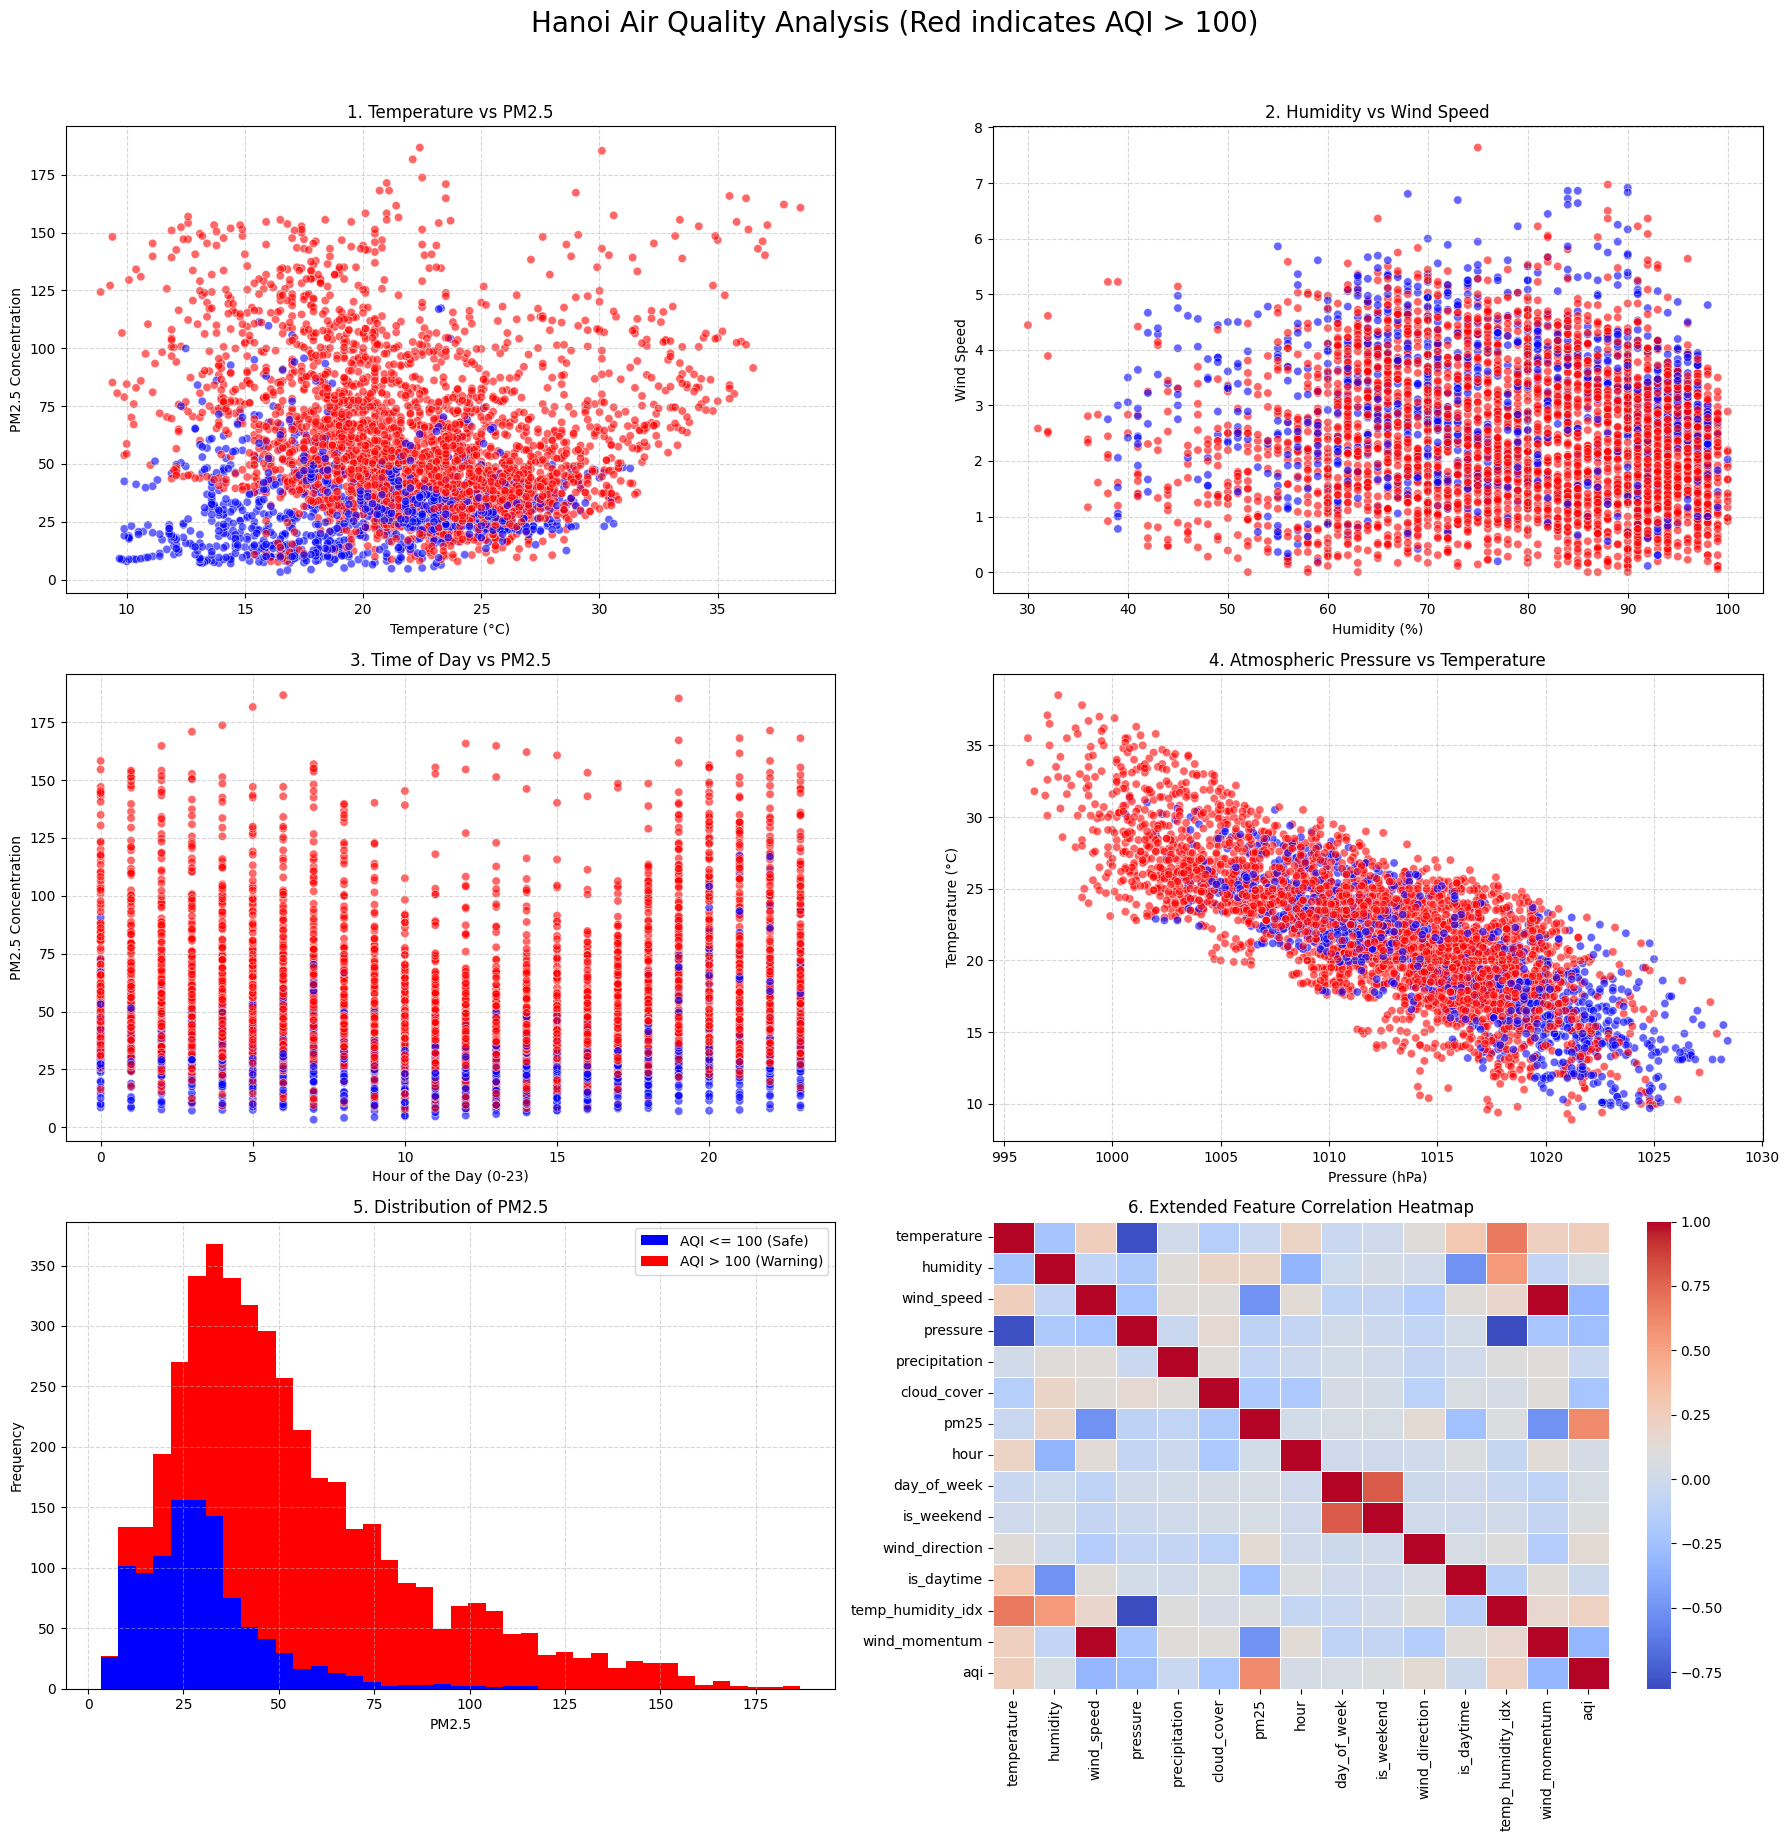

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# TASK 1: DATA COLLECTION, FEATURE ENGINEERING & PROCESSING
# ---------------------------------------------------------

# 1. Load the Data
file_path = '/kaggle/input/datasets/zohandam/hanoi-aqi-factors/hanoi_air_quality.csv'
df = pd.read_csv(file_path)

# 2. Feature Engineering (Creating MORE Features)
# Convert timestamp to datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Feature A: Is it daytime? (1 if between 6 AM and 6 PM, else 0)
df['is_daytime'] = df['hour'].apply(lambda x: 1 if 6 <= x <= 18 else 0)

# Feature B: Temperature-Humidity Index (proxy for perceived weather condition)
df['temp_humidity_idx'] = df['temperature'] * df['humidity']

# Feature C: Wind Momentum (Wind Speed adjusted by atmospheric pressure)
df['wind_momentum'] = df['wind_speed'] * df['pressure']

# Define Target and Expanded Features list (Now 14 features instead of 10)
target = 'is_warning'
features = [
    'temperature', 'humidity', 'wind_speed', 'pressure', 'precipitation', 
    'cloud_cover', 'pm25', 'hour', 'day_of_week', 'is_weekend',
    'wind_direction', 'is_daytime', 'temp_humidity_idx', 'wind_momentum'
]

X = df[features]
y = df[target]

# 3. Data Splitting & Normalization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Data Processing Summary ---")
print(f"Total Features Used: {len(features)}")
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples: {X_test_scaled.shape[0]}\n")


# ---------------------------------------------------------
# TASK 1: EXPANDED VISUALIZATIONS
# ---------------------------------------------------------

# Color array: Red if AQI > 100, otherwise Blue
colors = np.where(df['aqi'] > 100, 'red', 'blue')

# Setup a 3x2 grid for 6 distinct visualizations
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Hanoi Air Quality Analysis (Red indicates AQI > 100)', fontsize=20, y=1.02)

# Plot 1: Temperature vs PM2.5
axes[0,0].scatter(df['temperature'], df['pm25'], c=colors, alpha=0.6, edgecolors='w', linewidths=0.5)
axes[0,0].set_title('1. Temperature vs PM2.5')
axes[0,0].set_xlabel('Temperature (°C)')
axes[0,0].set_ylabel('PM2.5 Concentration')
axes[0,0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Humidity vs Wind Speed
axes[0,1].scatter(df['humidity'], df['wind_speed'], c=colors, alpha=0.6, edgecolors='w', linewidths=0.5)
axes[0,1].set_title('2. Humidity vs Wind Speed')
axes[0,1].set_xlabel('Humidity (%)')
axes[0,1].set_ylabel('Wind Speed')
axes[0,1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: Time of Day vs PM2.5
axes[1,0].scatter(df['hour'], df['pm25'], c=colors, alpha=0.6, edgecolors='w', linewidths=0.5)
axes[1,0].set_title('3. Time of Day vs PM2.5')
axes[1,0].set_xlabel('Hour of the Day (0-23)')
axes[1,0].set_ylabel('PM2.5 Concentration')
axes[1,0].grid(True, linestyle='--', alpha=0.5)

# Plot 4: Pressure vs Temperature
axes[1,1].scatter(df['pressure'], df['temperature'], c=colors, alpha=0.6, edgecolors='w', linewidths=0.5)
axes[1,1].set_title('4. Atmospheric Pressure vs Temperature')
axes[1,1].set_xlabel('Pressure (hPa)')
axes[1,1].set_ylabel('Temperature (°C)')
axes[1,1].grid(True, linestyle='--', alpha=0.5)

# Plot 5: Stacked Distribution of PM2.5
axes[2,0].hist([df[df['aqi'] <= 100]['pm25'], df[df['aqi'] > 100]['pm25']], 
         bins=40, stacked=True, color=['blue', 'red'], label=['AQI <= 100 (Safe)', 'AQI > 100 (Warning)'])
axes[2,0].set_title('5. Distribution of PM2.5')
axes[2,0].set_xlabel('PM2.5')
axes[2,0].set_ylabel('Frequency')
axes[2,0].legend()
axes[2,0].grid(True, linestyle='--', alpha=0.5)

# Plot 6: Expanded Correlation Heatmap
# Combining features and AQI just to show how the new features correlate with air quality
heatmap_cols = features + ['aqi']
sns.heatmap(df[heatmap_cols].corr(), annot=False, cmap='coolwarm', ax=axes[2,1], linewidths=0.5)
axes[2,1].set_title('6. Extended Feature Correlation Heatmap')

plt.tight_layout()
plt.show()